<a href="https://colab.research.google.com/github/Cami87029i/Inteligencia-Artificial-1/blob/main/Laboratorio4NG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np

# Manipulación de datos tabulares
import pandas as pd

# Libreria para graficos
from matplotlib import pyplot

# Modulo de optimizacion en scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Cargar los archivos del dataset Diabetes 130-US Hospitals
data = pd.read_csv("/content/drive/MyDrive/IA/diabetic_data.csv")
ids_mapping = pd.read_csv("/content/drive/MyDrive/IA/IDS_mapping.csv")

# Eliminar filas con '?' (valores faltantes)
data = data.replace('?', pd.NA)
for col in data.columns:
    data[col] = data[col].fillna(data[col].mode()[0])

# Codificar variables categóricas
for col in data.select_dtypes(include='object').columns:
    if col != 'readmitted':
        data[col] = pd.Categorical(data[col]).codes

# TARGET binario: 1 = readmitido en <30 días, 0 = otro
X = data.drop(columns=['readmitted']).values.astype(float)
y = (data['readmitted'] == '<30').astype(float).values

m = y.size

print(X.shape)
print(y.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(101766, 49)
(101766,)


In [ ]:
X.shape[1]

input_layer_size = X.shape[1]  # 367 automático
num_labels = 2                  # satisfecho o insatisfecho
m = y.size

In [ ]:
def calcularSigmoide(z):
    # Calcula la sigmoide de z.
    return 1.0 / (1.0 + np.exp(-z))

In [ ]:
def calcularCosto(theta, X, y, lambda_):
    # Inicializa algunos valores utiles
    m = y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)
    if m == 0:
        return J, grad

    h = calcularSigmoide(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)

    temp = theta
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
    # Se aplica regularizacion en la siguiente linea
    grad = grad + (lambda_ / m) * temp

    return J, grad

In [ ]:
# valores de prueba para los parámetros theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# valores de prueba para las entradas
X_t = np.concatenate((np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0), axis=1)
print(X_t)
# valores de testeo para las etiquetas
y_t = np.array([1, 0, 1, 0, 1])

# valores de testeo para el parametro de regularizacion
lambda_t = 3

[[1.  0.1 0.6 1.1]
 [1.  0.2 0.7 1.2]
 [1.  0.3 0.8 1.3]
 [1.  0.4 0.9 1.4]
 [1.  0.5 1.  1.5]]


In [ ]:
J, grad = calcularCosto(theta_t, X_t, y_t, lambda_t)

print('Costo         : {:.6f}'.format(J))
print('----')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))

Costo         : 2.534819
----
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]


In [ ]:
# Balancear clases
idx_clase0 = np.where(y == 0)[0]
idx_clase1 = np.where(y == 1)[0]

# Cuántos hay de cada clase
print(f"Clase 0: {len(idx_clase0)}")
print(f"Clase 1: {len(idx_clase1)}")

# Tomar la misma cantidad de la clase 0 que de la clase 1
np.random.seed(42)
idx_clase0_bal = np.random.choice(idx_clase0, len(idx_clase1), replace=False)

# Juntar y mezclar
idx_bal = np.concatenate([idx_clase0_bal, idx_clase1])
np.random.shuffle(idx_bal)

X = X[idx_bal]
y = y[idx_bal]

print(f"Total balanceado: {len(y)}")
print(f"Clase 0: {np.sum(y==0)}")

Clase 0: 90409
Clase 1: 11357
Total balanceado: 22714
Clase 0: 11357


In [ ]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # evitar división por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)
X = X_norm

In [ ]:
def oneVsAll(X, y, num_labels, lambda_):

    m, n = X.shape

    all_theta = np.zeros((num_labels, n + 1))

    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    costos=[]

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 500}
        res = optimize.minimize(calcularCosto,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='L-BFGS-B',
                                options=options)

        all_theta[c] = res.x

        costos.append(res.fun)

    return all_theta, costos

In [ ]:
lambda_ = 0.1
all_theta, costos = oneVsAll(X, y, num_labels, lambda_)

In [ ]:
print(all_theta)

[[-0.01990365  0.09185596 -0.04536599  0.00150918 -0.01120554 -0.07694155
   0.01137294  0.04064509 -0.14109633  0.01795985 -0.04964744 -0.01649456
  -0.0079896  -0.00454873  0.03156562 -0.04139477 -0.00744405 -0.05102012
  -0.48815513  0.03450612  0.02439015 -0.03018051 -0.09426325  0.01232882
   0.00623817  0.04493394 -0.01317116  0.00588894  0.03237573  0.04067403
   0.          0.00819305  0.02150952  0.01480505  0.02181058  0.01961253
  -0.00826839  0.01979063  0.         -0.00099473  0.          0.
   0.02395588  0.003084    0.00587643  0.06056043  0.05941677  0.
   0.0025394  -0.11669835]
 [ 0.01990365 -0.09185596  0.04536599 -0.00150918  0.01120554  0.07694155
  -0.01137294 -0.04064509  0.14109633 -0.01795985  0.04964744  0.01649456
   0.0079896   0.00454873 -0.03156562  0.04139477  0.00744405  0.05102012
   0.48815513 -0.03450612 -0.02439015  0.03018051  0.09426325 -0.01232882
  -0.00623817 -0.04493394  0.01317116 -0.00588894 -0.03237573 -0.04067403
   0.         -0.00819305 -

In [ ]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(calcularSigmoide(X.dot(all_theta.T)), axis=1)

    return p

In [ ]:
print(X.shape)
pred = predictOneVsAll(all_theta, X)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred == y) * 100))
idx_inicio = min(128, X.shape[0] - 13)
idx_fin = idx_inicio + 13
XPrueba = X[128:141, :].copy()
yPrueba = y[128:141].copy()
print(XPrueba.shape)
print(len(XPrueba))

XPrueba = np.concatenate((np.ones((len(XPrueba), 1)), XPrueba), axis=1)
print(XPrueba)
p = np.argmax(calcularSigmoide(XPrueba.dot(all_theta.T)), axis=1)
print(p)  # ← sin el + 1

(22714, 49)
Precision del conjuto de entrenamiento: 59.96%
(13, 49)
13
[[ 1.00000000e+00 -6.63696527e-01 -1.26554048e+00 -1.95130569e+00
   1.08111753e+00 -8.58424334e-02  1.08691267e-01 -2.88853803e-03
  -1.84650316e-01 -1.18898926e+00  4.79339604e-01 -2.36958262e-02
   2.37075308e+00 -4.39804412e-01 -7.81982757e-01 -5.29259983e-02
  -3.10982205e-01 -2.25493195e-01 -5.47369572e-01 -3.02068230e-01
   1.51618903e+00 -6.03412843e-03 -1.36621640e+00  1.66836770e-01
  -3.76318131e-02 -4.26665517e-01 -1.18577676e-01 -7.97281334e-02
  -2.75208312e-02 -2.04412219e-01  0.00000000e+00 -3.29308776e-01
  -2.94480871e-01 -1.32715433e-02 -2.60431354e-01 -2.46810246e-01
  -4.53511904e-02 -1.06405728e-02  0.00000000e+00 -1.62549704e-02
   0.00000000e+00  0.00000000e+00  6.82736120e-01 -8.23574601e-02
  -1.14932406e-02 -6.63533340e-03 -6.63533340e-03  0.00000000e+00
   9.55973891e-01  5.27126328e-01]
 [ 1.00000000e+00 -8.93576362e-01 -4.41243175e-01  3.96193446e-01
  -9.24641156e-01  5.44760747e-01  1

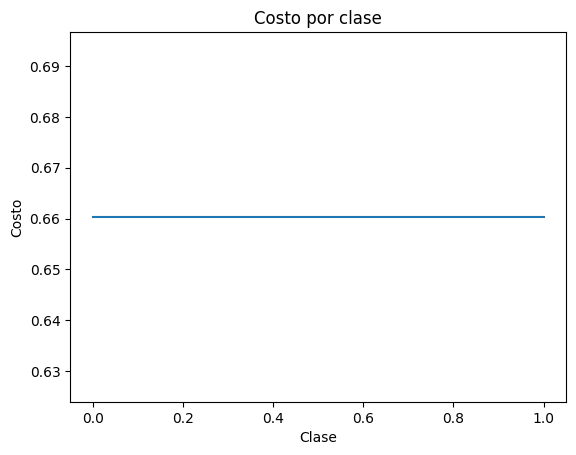

In [ ]:
pyplot.plot(costos)
pyplot.xlabel('Clase')
pyplot.ylabel('Costo')
pyplot.title('Costo por clase')
pyplot.show()

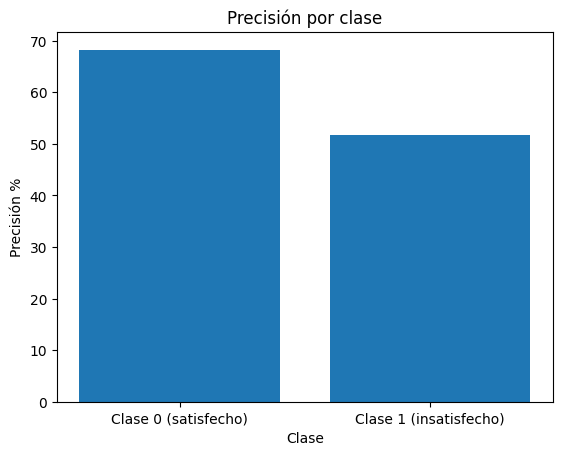

In [ ]:
pred = predictOneVsAll(all_theta, X)

precisiones = []
for c in np.arange(num_labels):
    mask = (y == c)
    precision_clase = np.mean(pred[mask] == y[mask]) * 100
    precisiones.append(precision_clase)

pyplot.bar([0, 1], precisiones)                                          # ← cambio
pyplot.xticks([0, 1], ['Clase 0 (satisfecho)', 'Clase 1 (insatisfecho)'])
pyplot.xlabel('Clase')
pyplot.ylabel('Precisión %')
pyplot.title('Precisión por clase')
pyplot.show()